# **Projeto de Graduação em Computação II [2026-Q1]**

Universidade Federal do ABC

Orientador Carlos da Silva dos Santos

### **EQUIPE**

---

Caio Cardoso Dos Santos - RA: 11202021632

Victor Ravazio de Lima - RA: 11201920941

### **IMPLEMENTAÇÃO**
---

In [1]:
# modulo para importar dataset a partir de um link
!pip install gdown

In [2]:
#Bibliotecas
import pandas as pd
import numpy as np
from google.colab import files
import gdown
import matplotlib.pyplot as plt
import random
import seaborn as sns

In [3]:
#Variaveis de controle
anotado = 400
# num_replys_anotados = 150
# num_quotes_anotados = 150
# num_originals_anotados = 150

In [4]:
# baixando dataset para o collab
import gdown

file_class_caio = "1lM2oD3feMLsXeX-i6LqAtj3_syH-Swuu"
file_class_victor = "1FQQ9t-tGo04dIJ6LSGN3fesM2SU6GNrf"
url_1 = f"https://drive.google.com/uc?id={file_class_caio}"
url_2 = f"https://drive.google.com/uc?id={file_class_victor}"

gdown.download(url_1, "cloroquina_anotado_caio.csv", quiet=False)
gdown.download(url_2, "cloroquina_anotado_victor.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1lM2oD3feMLsXeX-i6LqAtj3_syH-Swuu
To: /content/cloroquina_anotado_caio.csv
100%|██████████| 12.4M/12.4M [00:00<00:00, 51.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1FQQ9t-tGo04dIJ6LSGN3fesM2SU6GNrf
To: /content/cloroquina_anotado_victor.csv
100%|██████████| 12.4M/12.4M [00:00<00:00, 99.2MB/s]


'cloroquina_anotado_victor.csv'

In [5]:
#carregando o dataset
df_caio = pd.read_csv ("cloroquina_anotado_caio.csv")
df_victor = pd.read_csv ("cloroquina_anotado_victor.csv")

In [6]:
#numero total de instancias no dataset
df_caio.shape

(42907, 6)

In [7]:
#numero total de instancias no dataset
df_victor.shape

(42907, 6)

In [8]:
df_caio.head(20)

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,Bolsonaro finalmente conseguiu forçar o Min. d...,Espero que vc é tds a sua volta fiquem a salvo...,1,0.023291,0.976709,1.0
1,"- Ainda não existe comprovação científica, mas...",Fez um inferno pra liberar esse caralho de med...,2,0.028428,0.971572,1.0
2,Bolsonaro finalmente conseguiu forçar o Min. d...,"Queria ver essa anta dessa Sâmia, fudida no ho...",1,0.029673,0.970327,1.0
3,"- Ainda não existe comprovação científica, mas...",vc é uma criança mimada e pirracenta. desleixa...,1,0.030431,0.969569,1.0
4,"- Ainda não existe comprovação científica, mas...","""Não existe comprovação científica"" Porra pres...",2,0.030527,0.969473,1.0
5,Bolsonaro finalmente conseguiu forçar o Min. d...,É só não tomar... Todo este discurso murcha qu...,1,0.030933,0.969067,1.0
6,"Quer dar placebo pro povo? Dê, não tem problem...",Ta ligado que o Curitiba é uma das cidades com...,1,0.032048,0.967952,1.0
7,"- Ainda não existe comprovação científica, mas...",foco no “não existe comprovação científica”,2,0.033538,0.966462,1.0
8,"- Ainda não existe comprovação científica, mas...","Presta atenção no ""NÃO EXISTE COMPROVAÇÃO CIE...",2,0.033968,0.966032,1.0
9,Bolsonaro finalmente conseguiu forçar o Min. d...,A cloroquina existe desde 1955.2 meses atrás e...,1,0.034570,0.965430,1.0


In [9]:
df_victor.head(20)

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,Bolsonaro finalmente conseguiu forçar o Min. d...,Espero que vc é tds a sua volta fiquem a salvo...,1,0.023291,0.976709,1.0
1,"- Ainda não existe comprovação científica, mas...",Fez um inferno pra liberar esse caralho de med...,2,0.028428,0.971572,1.0
2,Bolsonaro finalmente conseguiu forçar o Min. d...,"Queria ver essa anta dessa Sâmia, fudida no ho...",1,0.029673,0.970327,1.0
3,"- Ainda não existe comprovação científica, mas...",vc é uma criança mimada e pirracenta. desleixa...,1,0.030431,0.969569,1.0
4,"- Ainda não existe comprovação científica, mas...","""Não existe comprovação científica"" Porra pres...",2,0.030527,0.969473,1.0
5,Bolsonaro finalmente conseguiu forçar o Min. d...,É só não tomar... Todo este discurso murcha qu...,1,0.030933,0.969067,1.0
6,"Quer dar placebo pro povo? Dê, não tem problem...",Ta ligado que o Curitiba é uma das cidades com...,1,0.032048,0.967952,1.0
7,"- Ainda não existe comprovação científica, mas...",foco no “não existe comprovação científica”,2,0.033538,0.966462,1.0
8,"- Ainda não existe comprovação científica, mas...","Presta atenção no ""NÃO EXISTE COMPROVAÇÃO CIE...",2,0.033968,0.966032,1.0
9,Bolsonaro finalmente conseguiu forçar o Min. d...,A cloroquina existe desde 1955.2 meses atrás e...,1,0.034570,0.965430,1.0


# **Analise Exploratória**



In [10]:
df_remaining = df_caio.iloc[anotado:,:]

In [11]:
# restrigindo por quantidade anotada
df_caio = df_caio.iloc[:anotado,:]
df_caio['Conflict'] = df_caio['Conflict'].astype(int) #convertendo valores para inteiros
df_victor = df_victor.iloc[:anotado,:]
df_victor['Conflict'] = df_victor['Conflict'].astype(int)

In [12]:
#separando por classe

In [13]:
df_caio

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,Bolsonaro finalmente conseguiu forçar o Min. d...,Espero que vc é tds a sua volta fiquem a salvo...,1,0.023291,0.976709,1
1,"- Ainda não existe comprovação científica, mas...",Fez um inferno pra liberar esse caralho de med...,2,0.028428,0.971572,1
2,Bolsonaro finalmente conseguiu forçar o Min. d...,"Queria ver essa anta dessa Sâmia, fudida no ho...",1,0.029673,0.970327,1
3,"- Ainda não existe comprovação científica, mas...",vc é uma criança mimada e pirracenta. desleixa...,1,0.030431,0.969569,1
4,"- Ainda não existe comprovação científica, mas...","""Não existe comprovação científica"" Porra pres...",2,0.030527,0.969473,1
...,...,...,...,...,...,...
395,"Vc não parece estar bem, já tomou sua dose de ...","Quem entende de cheirar é a Esquerda, principa...",1,0.066160,0.933840,1
396,Apresentei um projeto de decreto legislativo p...,Na realidade o medo da oposição e de pessoas c...,1,0.066180,0.933820,1
397,"- Ainda não existe comprovação científica, mas...","Não preciza de ciensia capetao bozonaro, basta...",2,0.066188,0.933812,1
398,Bolsonaro admite que não há comprovação cientí...,Depois de produzir o medicamento em grande esc...,2,0.066224,0.933776,0


In [14]:
df_victor

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,Bolsonaro finalmente conseguiu forçar o Min. d...,Espero que vc é tds a sua volta fiquem a salvo...,1,0.023291,0.976709,1
1,"- Ainda não existe comprovação científica, mas...",Fez um inferno pra liberar esse caralho de med...,2,0.028428,0.971572,1
2,Bolsonaro finalmente conseguiu forçar o Min. d...,"Queria ver essa anta dessa Sâmia, fudida no ho...",1,0.029673,0.970327,1
3,"- Ainda não existe comprovação científica, mas...",vc é uma criança mimada e pirracenta. desleixa...,1,0.030431,0.969569,1
4,"- Ainda não existe comprovação científica, mas...","""Não existe comprovação científica"" Porra pres...",2,0.030527,0.969473,1
...,...,...,...,...,...,...
395,"Vc não parece estar bem, já tomou sua dose de ...","Quem entende de cheirar é a Esquerda, principa...",1,0.066160,0.933840,1
396,Apresentei um projeto de decreto legislativo p...,Na realidade o medo da oposição e de pessoas c...,1,0.066180,0.933820,1
397,"- Ainda não existe comprovação científica, mas...","Não preciza de ciensia capetao bozonaro, basta...",2,0.066188,0.933812,1
398,Bolsonaro admite que não há comprovação cientí...,Depois de produzir o medicamento em grande esc...,2,0.066224,0.933776,0


In [15]:
confusion = np.zeros((3,3))

idx_diff = []  # lista com os índices i onde as classificações diferem

In [16]:
for i in range(df_caio.shape[0]):
  caio = int(df_caio.iloc[i]["Conflict"])
  victor = int(df_victor.iloc[i]["Conflict"])

  # mapeia -1 para 2 para a matriz 3x3
  row = 2 if caio == -1 else caio
  col = 2 if victor == -1 else victor

  confusion[row][col] += 1

  # se são diferentes (fora da diagonal principal)
  if row != col:
    idx_diff.append(i)

In [17]:
confusion

array([[149.,  22.,   2.],
       [  9., 202.,   1.],
       [  3.,   8.,   4.]])

In [18]:
idx_diff

[23,
 24,
 26,
 29,
 32,
 35,
 41,
 54,
 62,
 72,
 76,
 81,
 87,
 88,
 92,
 104,
 107,
 109,
 119,
 128,
 130,
 159,
 170,
 172,
 175,
 183,
 186,
 188,
 194,
 198,
 199,
 214,
 221,
 256,
 257,
 258,
 283,
 303,
 308,
 319,
 332,
 333,
 334,
 346,
 366]

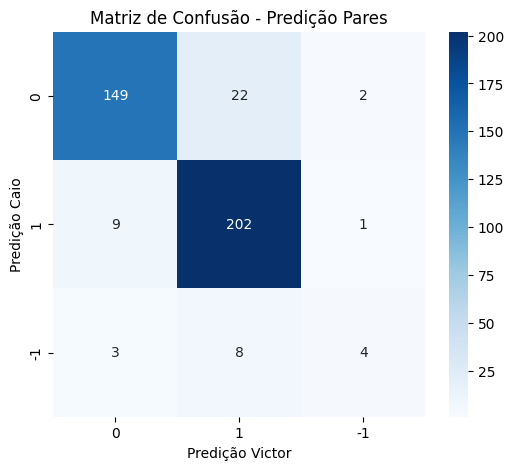

In [19]:
labels = ["0", "1", "-1"] # classes

plt.figure(figsize=(6,5))
sns.heatmap(confusion, annot=True, fmt=".0f", cmap="Blues", xticklabels=labels, yticklabels=labels) #desenha a matriz de confusão como uma "matriz de calor"

plt.xlabel("Predição Victor")
plt.ylabel("Predição Caio")
plt.title("Matriz de Confusão - Predição Pares")
plt.show()

In [20]:
mapa = {-1: "Indeterminado", 0: "Não Conflito", 1: "Conflito"}
mapa_tipo = {0: "Genérico", 1: "Reply", 2: "Quote"}

for i in range(len(idx_diff)):
  print("Tipo: ", mapa_tipo[int(df_caio.loc[idx_diff[i], "Class"])])
  print("Tweet 1: ", df_caio.loc[idx_diff[i], "tweet_1"])
  print("Tweet 2: ", df_caio.loc[idx_diff[i], "tweet_2"])
  print("Classificação Caio: ", mapa[int(df_caio.loc[idx_diff[i], "Conflict"])])
  print("Classificação Victor: ", mapa[int(df_victor.loc[idx_diff[i], "Conflict"])])
  print()

Tipo:  Reply
Tweet 1:  Bolsonaro quer aplicar Cloroquina a qualquer custo. Porém, o paciente precisará assinar um termo de ciência que NÃO existem dados sobre a eficiência para Covid-19 e que está ciente que pode sofrer uma parada cardíaca. Você vira cobaia do Presidente e o isenta de responsabilidade.
Tweet 2:  tá na hora de deixar essa cloroquina quieta, e deixar o médico e o paciente resolverem essa questão;
Classificação Caio:  Não Conflito
Classificação Victor:  Conflito

Tipo:  Genérico
Tweet 1:  A discussão sobre Cloroquina é falsa. Ela nunca foi proibida, nem será obrigatória. Os médicos mais atualizados, só prescrevem seguindo preceitos cientificos. Já os charlatões, usam de forma massiva pq nunca precisaram da ciência. A pressão do Bolsonaro não muda essa realidade.
Tweet 2:  Imprensa imunda e os esquerdopatas lutando contra o uso da Cloroquina, estes imbecis já leram a bula da dipirona, que vc compra em qualquer padaria da esquina?
Classificação Caio:  Não Conflito
Classific

In [21]:
#CLASSIFICAÇÕES POR CLASSES CAIO
print("CLASSIFICAÇÕES POR CLASSES CAIO:")
print("Cloroquina:")
print("Conflito:", df_caio[df_caio['Conflict'] == 1].shape[0])
print("Não conflito:", df_caio[df_caio['Conflict'] == 0].shape[0])
print("Indeterminado:", df_caio[df_caio['Conflict'] == -1].shape[0])

CLASSIFICAÇÕES POR CLASSES CAIO:
Cloroquina:
Conflito: 212
Não conflito: 173
Indeterminado: 15


In [22]:
#CLASSIFICAÇÕES POR CLASSES VICTOR
print("CLASSIFICAÇÕES POR CLASSES VICTOR:")
print("Cloroquina:")
print("Conflito:", df_victor[df_victor['Conflict'] == 1].shape[0])
print("Não conflito:", df_victor[df_victor['Conflict'] == 0].shape[0])
print("Indeterminado:", df_victor[df_victor['Conflict'] == -1].shape[0])

CLASSIFICAÇÕES POR CLASSES VICTOR:
Cloroquina:
Conflito: 232
Não conflito: 161
Indeterminado: 7


In [23]:
#Distribuição de conflitos por classes CAIO

#Separando as classes
reply_caio = df_caio[df_caio['Class'] == 1]
quote_caio = df_caio[df_caio['Class'] == 2]
original_caio = df_caio[df_caio['Class'] == 0]
print("Distribuição de conflitos por classes CAIO:")
print("Replys anotados:", reply_caio.shape[0])
print("Conflitos:", reply_caio[reply_caio['Conflict'] == 1].shape[0])
print("Não conflitos:", reply_caio[reply_caio['Conflict'] == 0].shape[0])
print()
print("Quote anotados:", quote_caio.shape[0])
print("Conflitos:", quote_caio[quote_caio['Conflict'] == 1].shape[0])
print("Não conflitos:", quote_caio[quote_caio['Conflict'] == 0].shape[0])
print()
print("Originals anotados:", original_caio.shape[0])
print("Conflitos:", original_caio[original_caio['Conflict'] == 1].shape[0])
print("Não conflitos:", original_caio[original_caio['Conflict'] == 0].shape[0])

Distribuição de conflitos por classes CAIO:
Replys anotados: 189
Conflitos: 125
Não conflitos: 62

Quote anotados: 154
Conflitos: 80
Não conflitos: 65

Originals anotados: 57
Conflitos: 7
Não conflitos: 46


In [24]:
#Distribuição de conflitos por classes VICTOR

#Separando as classes
reply_victor = df_victor[df_victor['Class'] == 1]
quote_victor = df_victor[df_victor['Class'] == 2]
original_victor = df_victor[df_victor['Class'] == 0]
print("Distribuição de conflitos por classes VICTOR:")
print("Replys anotados:", reply_victor.shape[0])
print("Conflitos:", reply_victor[reply_victor['Conflict'] == 1].shape[0])
print("Não conflitos:", reply_victor[reply_victor['Conflict'] == 0].shape[0])
print()
print("Quote anotados:", quote_victor.shape[0])
print("Conflitos:", quote_victor[quote_victor['Conflict'] == 1].shape[0])
print("Não conflitos:", quote_victor[quote_victor['Conflict'] == 0].shape[0])
print()
print("Originals anotados:", original_victor.shape[0])
print("Conflitos:", original_victor[original_victor['Conflict'] == 1].shape[0])
print("Não conflitos:", original_victor[original_victor['Conflict'] == 0].shape[0])

Distribuição de conflitos por classes VICTOR:
Replys anotados: 189
Conflitos: 131
Não conflitos: 56

Quote anotados: 154
Conflitos: 87
Não conflitos: 62

Originals anotados: 57
Conflitos: 14
Não conflitos: 43


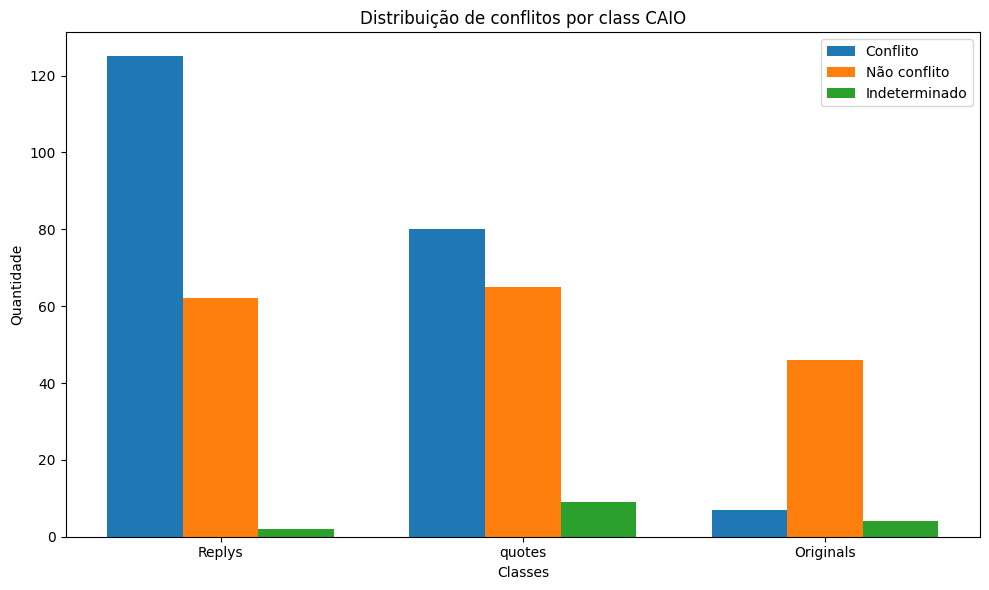

In [25]:
# grafico
# Registando as contagens de classificações por estruturas
classes = ['Replys', 'quotes', 'Originals']

conflitos = [
    reply_caio[reply_caio['Conflict'] == 1].shape[0],
    quote_caio[quote_caio['Conflict'] == 1].shape[0],
    original_caio[original_caio['Conflict'] == 1].shape[0]
]

nao_conflitos = [
    reply_caio[reply_caio['Conflict'] == 0].shape[0],
    quote_caio[quote_caio['Conflict'] == 0].shape[0],
    original_caio[original_caio['Conflict'] == 0].shape[0]
]

indeterminados = [
    reply_caio[reply_caio['Conflict'] == -1].shape[0],
    quote_caio[quote_caio['Conflict'] == -1].shape[0],
    original_caio[original_caio['Conflict'] == -1].shape[0]
]



# Posição das barras

x = np.arange(len(classes))

largura = 0.25

#desenhando o grafico

plt.figure(figsize=(10,6))

plt.bar(x - largura, conflitos,
        width=largura,
        label='Conflito')

plt.bar(x, nao_conflitos,
        width=largura,
        label='Não conflito')

plt.bar(x + largura, indeterminados,
        width=largura,
        label='Indeterminado')

plt.xticks(x, classes)

plt.xlabel("Classes")
plt.ylabel("Quantidade")

plt.title("Distribuição de conflitos por class CAIO")

plt.legend()

plt.tight_layout()

plt.show()

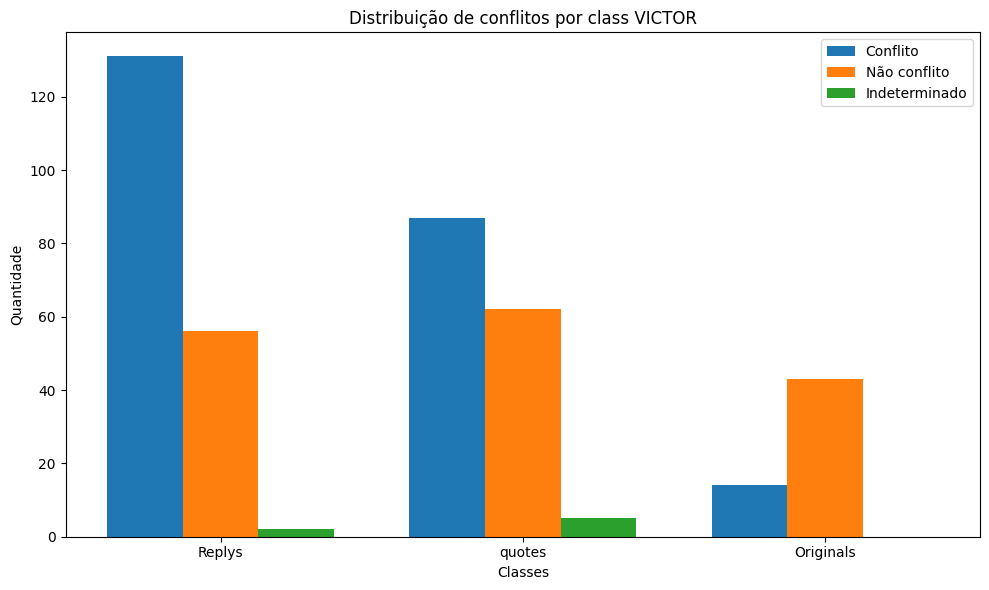

In [26]:
# grafico
# Registando as contagens de classificações por estruturas
classes = ['Replys', 'quotes', 'Originals']

conflitos = [
    reply_victor[reply_victor['Conflict'] == 1].shape[0],
    quote_victor[quote_victor['Conflict'] == 1].shape[0],
    original_victor[original_victor['Conflict'] == 1].shape[0]
]

nao_conflitos = [
    reply_victor[reply_victor['Conflict'] == 0].shape[0],
    quote_victor[quote_victor['Conflict'] == 0].shape[0],
    original_victor[original_victor['Conflict'] == 0].shape[0]
]

indeterminados = [
    reply_victor[reply_victor['Conflict'] == -1].shape[0],
    quote_victor[quote_victor['Conflict'] == -1].shape[0],
    original_victor[original_victor['Conflict'] == -1].shape[0]
]



# Posição das barras

x = np.arange(len(classes))

largura = 0.25

#desenhando o grafico

plt.figure(figsize=(10,6))

plt.bar(x - largura, conflitos,
        width=largura,
        label='Conflito')

plt.bar(x, nao_conflitos,
        width=largura,
        label='Não conflito')

plt.bar(x + largura, indeterminados,
        width=largura,
        label='Indeterminado')

plt.xticks(x, classes)

plt.xlabel("Classes")
plt.ylabel("Quantidade")

plt.title("Distribuição de conflitos por class VICTOR")

plt.legend()

plt.tight_layout()

plt.show()

In [27]:
# Previsoes incorretas CAIO:
df_inc_caio = df_caio[(df_caio['P(Conflict)'] > 0.5) & (df_caio['Conflict'] != 1)]
df_inc_caio.shape

(131, 6)

In [28]:
# Previsoes incorretas VICTOR:
df_inc_victor = df_victor[(df_victor['P(Conflict)'] > 0.5) & (df_victor['Conflict'] != 1)]
df_inc_victor.shape

(116, 6)

In [29]:
#Erros por classe de tweet CAIO
print("Erros por classe de tweet:")
print("Replys:", df_inc_caio[df_inc_caio['Class'] == 1].shape[0])
print("Quotes:", df_inc_caio[df_inc_caio['Class'] == 2].shape[0])
print("Originals:", df_inc_caio[df_inc_caio['Class'] == 0].shape[0])

Erros por classe de tweet:
Replys: 44
Quotes: 60
Originals: 27


In [30]:
#Erros por classe de tweet VICTOR
print("Erros por classe de tweet:")
print("Replys:", df_inc_victor[df_inc_victor['Class'] == 1].shape[0])
print("Quotes:", df_inc_victor[df_inc_victor['Class'] == 2].shape[0])
print("Originals:", df_inc_victor[df_inc_victor['Class'] == 0].shape[0])

Erros por classe de tweet:
Replys: 40
Quotes: 53
Originals: 23


In [31]:
#Organizando classificações de conflitos de Caio e Victor em um unico DF
df = df_caio.drop('Conflict', axis = 1)
df['Conflict_Caio'] = df_caio['Conflict']
df['Conflict_Victor'] = df_victor['Conflict']

In [32]:
df

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict_Caio,Conflict_Victor
0,Bolsonaro finalmente conseguiu forçar o Min. d...,Espero que vc é tds a sua volta fiquem a salvo...,1,0.023291,0.976709,1,1
1,"- Ainda não existe comprovação científica, mas...",Fez um inferno pra liberar esse caralho de med...,2,0.028428,0.971572,1,1
2,Bolsonaro finalmente conseguiu forçar o Min. d...,"Queria ver essa anta dessa Sâmia, fudida no ho...",1,0.029673,0.970327,1,1
3,"- Ainda não existe comprovação científica, mas...",vc é uma criança mimada e pirracenta. desleixa...,1,0.030431,0.969569,1,1
4,"- Ainda não existe comprovação científica, mas...","""Não existe comprovação científica"" Porra pres...",2,0.030527,0.969473,1,1
...,...,...,...,...,...,...,...
395,"Vc não parece estar bem, já tomou sua dose de ...","Quem entende de cheirar é a Esquerda, principa...",1,0.066160,0.933840,1,1
396,Apresentei um projeto de decreto legislativo p...,Na realidade o medo da oposição e de pessoas c...,1,0.066180,0.933820,1,1
397,"- Ainda não existe comprovação científica, mas...","Não preciza de ciensia capetao bozonaro, basta...",2,0.066188,0.933812,1,1
398,Bolsonaro admite que não há comprovação cientí...,Depois de produzir o medicamento em grande esc...,2,0.066224,0.933776,0,0


In [33]:
df.to_csv("cloroquina_induzido_classificado.csv", index=False, encoding="utf-8")
files.download("cloroquina_induzido_classificado.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Criando Dataset das divergencias**

In [34]:
div = df_caio.iloc[idx_diff].drop('Conflict', axis=1)
div['Conflict_caio'] = df_caio['Conflict'].iloc[idx_diff].astype(int)
div['Conflict_victor'] = df_victor['Conflict'].iloc[idx_diff].astype(int)
div['Conflict'] = np.nan

In [35]:
div.shape

(45, 8)

In [36]:
div

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict_caio,Conflict_victor,Conflict
23,Bolsonaro quer aplicar Cloroquina a qualquer c...,"tá na hora de deixar essa cloroquina quieta, e...",1,0.059927,0.940073,0,1,NaN
24,A discussão sobre Cloroquina é falsa. Ela nunc...,Imprensa imunda e os esquerdopatas lutando con...,0,0.067427,0.932573,0,1,NaN
26,"“Redução dos glóbulos brancos, disfunção do fí...",Meu avô começou tomar cloroquina com 80 anos p...,1,0.075467,0.924533,1,0,NaN
29,Os médicos concordam que a proposta de tratame...,Se a cloroquina é a tal pq o paciente tem q as...,1,0.080986,0.919014,0,1,NaN
32,Vi no Jornal da Globo uma descrição dos efeito...,"Ja leu as bulas da DIPIRONA, AS, e de outros c...",2,0.082830,0.917170,0,1,NaN
35,Tomo cloroquina há 16 anos. A dosagem é super-...,Creio que seja controlada a dosagem ...e não f...,1,0.098667,0.901333,0,1,NaN
41,"Calma, bando de 0tári0. O tratamento está aca...",Otários? Se existe um tratamento preventivo qu...,2,0.120484,0.879516,0,1,NaN
54,Acha mesmo q o brasileiro com pouco esclarecim...,"Tenho parente que tem esclerose Múltipla , tom...",1,0.165254,0.834746,0,1,NaN
62,"""tem tbm as pessoas q foram medicadas e recupe...",Mtas pessoas foram recuperadas com vários trat...,1,0.185597,0.814403,0,1,NaN
72,"- Ainda não existe comprovação científica, mas...","não sou homofóbico, mas...",2,0.240157,0.759843,0,-1,NaN


In [37]:
div_aborto_final = div.drop(columns=['Conflict_caio', 'Conflict_victor'])
div_aborto_final

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
23,Bolsonaro quer aplicar Cloroquina a qualquer c...,"tá na hora de deixar essa cloroquina quieta, e...",1,0.059927,0.940073,NaN
24,A discussão sobre Cloroquina é falsa. Ela nunc...,Imprensa imunda e os esquerdopatas lutando con...,0,0.067427,0.932573,NaN
26,"“Redução dos glóbulos brancos, disfunção do fí...",Meu avô começou tomar cloroquina com 80 anos p...,1,0.075467,0.924533,NaN
29,Os médicos concordam que a proposta de tratame...,Se a cloroquina é a tal pq o paciente tem q as...,1,0.080986,0.919014,NaN
32,Vi no Jornal da Globo uma descrição dos efeito...,"Ja leu as bulas da DIPIRONA, AS, e de outros c...",2,0.082830,0.917170,NaN
35,Tomo cloroquina há 16 anos. A dosagem é super-...,Creio que seja controlada a dosagem ...e não f...,1,0.098667,0.901333,NaN
41,"Calma, bando de 0tári0. O tratamento está aca...",Otários? Se existe um tratamento preventivo qu...,2,0.120484,0.879516,NaN
54,Acha mesmo q o brasileiro com pouco esclarecim...,"Tenho parente que tem esclerose Múltipla , tom...",1,0.165254,0.834746,NaN
62,"""tem tbm as pessoas q foram medicadas e recupe...",Mtas pessoas foram recuperadas com vários trat...,1,0.185597,0.814403,NaN
72,"- Ainda não existe comprovação científica, mas...","não sou homofóbico, mas...",2,0.240157,0.759843,NaN


In [38]:
div_aborto_final.to_csv("divergencias_cloroquina_induzido.csv", index=False, encoding="utf-8")
files.download("divergencias_cloroquina_induzido.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Criando Dataset das Convergencias**




In [39]:
conv_aborto = df_caio.drop(index=idx_diff, errors='ignore')
conv_aborto.shape

(355, 6)

In [40]:
conv_aborto

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,Bolsonaro finalmente conseguiu forçar o Min. d...,Espero que vc é tds a sua volta fiquem a salvo...,1,0.023291,0.976709,1
1,"- Ainda não existe comprovação científica, mas...",Fez um inferno pra liberar esse caralho de med...,2,0.028428,0.971572,1
2,Bolsonaro finalmente conseguiu forçar o Min. d...,"Queria ver essa anta dessa Sâmia, fudida no ho...",1,0.029673,0.970327,1
3,"- Ainda não existe comprovação científica, mas...",vc é uma criança mimada e pirracenta. desleixa...,1,0.030431,0.969569,1
4,"- Ainda não existe comprovação científica, mas...","""Não existe comprovação científica"" Porra pres...",2,0.030527,0.969473,1
...,...,...,...,...,...,...
395,"Vc não parece estar bem, já tomou sua dose de ...","Quem entende de cheirar é a Esquerda, principa...",1,0.066160,0.933840,1
396,Apresentei um projeto de decreto legislativo p...,Na realidade o medo da oposição e de pessoas c...,1,0.066180,0.933820,1
397,"- Ainda não existe comprovação científica, mas...","Não preciza de ciensia capetao bozonaro, basta...",2,0.066188,0.933812,1
398,Bolsonaro admite que não há comprovação cientí...,Depois de produzir o medicamento em grande esc...,2,0.066224,0.933776,0


In [41]:
#juntando anotações do professor (QUANDO ELE ANOTAR)
#adicionando as classificações do professor
file_class_prof = "1PX2LZIkSzt9a_PsByQ0yZYnKD6FPdGIF"
url = f"https://drive.google.com/uc?id={file_class_prof}"
gdown.download(url, "class_prof.csv", quiet=False)
df_class_prof = pd.read_csv ("class_prof.csv")

Downloading...
From: https://drive.google.com/uc?id=1PX2LZIkSzt9a_PsByQ0yZYnKD6FPdGIF
To: /content/class_prof.csv
100%|██████████| 17.6k/17.6k [00:00<00:00, 24.2MB/s]


In [42]:
df_class_prof

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,Bolsonaro quer aplicar Cloroquina a qualquer c...,"tá na hora de deixar essa cloroquina quieta, e...",1,0.059927,0.940073,0
1,A discussão sobre Cloroquina é falsa. Ela nunc...,Imprensa imunda e os esquerdopatas lutando con...,0,0.067427,0.932573,1
2,"“Redução dos glóbulos brancos, disfunção do fí...",Meu avô começou tomar cloroquina com 80 anos p...,1,0.075467,0.924533,0
3,Os médicos concordam que a proposta de tratame...,Se a cloroquina é a tal pq o paciente tem q as...,1,0.080986,0.919014,-1
4,Vi no Jornal da Globo uma descrição dos efeito...,"Ja leu as bulas da DIPIRONA, AS, e de outros c...",2,0.082830,0.917170,0
5,Tomo cloroquina há 16 anos. A dosagem é super-...,Creio que seja controlada a dosagem ...e não f...,1,0.098667,0.901333,0
6,"Calma, bando de 0tári0. O tratamento está aca...",Otários? Se existe um tratamento preventivo qu...,2,0.120484,0.879516,-1
7,Acha mesmo q o brasileiro com pouco esclarecim...,"Tenho parente que tem esclerose Múltipla , tom...",1,0.165254,0.834746,0
8,"""tem tbm as pessoas q foram medicadas e recupe...",Mtas pessoas foram recuperadas com vários trat...,1,0.185597,0.814403,0
9,"- Ainda não existe comprovação científica, mas...","não sou homofóbico, mas...",2,0.240157,0.759843,-1


In [43]:
df_desempate = div.merge(df_class_prof, on=['tweet_1', 'tweet_2'], how='inner')
df_desempate = df_desempate.drop(columns=['Conflict_x', 'Class_y', 'P(NoConflict)_y', 'P(Conflict)_y'])
df_desempate = df_desempate.rename(columns={'Class_x': 'Class', 'P(NoConflict)_x': 'P(NoConflict)', 'P(Conflict)_x': 'P(Conflict)', 'Conflict_y': 'Conflict_prof' })
df_desempate

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict_caio,Conflict_victor,Conflict_prof
0,Bolsonaro quer aplicar Cloroquina a qualquer c...,"tá na hora de deixar essa cloroquina quieta, e...",1,0.059927,0.940073,0,1,0
1,A discussão sobre Cloroquina é falsa. Ela nunc...,Imprensa imunda e os esquerdopatas lutando con...,0,0.067427,0.932573,0,1,1
2,"“Redução dos glóbulos brancos, disfunção do fí...",Meu avô começou tomar cloroquina com 80 anos p...,1,0.075467,0.924533,1,0,0
3,Os médicos concordam que a proposta de tratame...,Se a cloroquina é a tal pq o paciente tem q as...,1,0.080986,0.919014,0,1,-1
4,Vi no Jornal da Globo uma descrição dos efeito...,"Ja leu as bulas da DIPIRONA, AS, e de outros c...",2,0.082830,0.917170,0,1,0
5,Tomo cloroquina há 16 anos. A dosagem é super-...,Creio que seja controlada a dosagem ...e não f...,1,0.098667,0.901333,0,1,0
6,"Calma, bando de 0tári0. O tratamento está aca...",Otários? Se existe um tratamento preventivo qu...,2,0.120484,0.879516,0,1,-1
7,Acha mesmo q o brasileiro com pouco esclarecim...,"Tenho parente que tem esclerose Múltipla , tom...",1,0.165254,0.834746,0,1,0
8,"""tem tbm as pessoas q foram medicadas e recupe...",Mtas pessoas foram recuperadas com vários trat...,1,0.185597,0.814403,0,1,0
9,"- Ainda não existe comprovação científica, mas...","não sou homofóbico, mas...",2,0.240157,0.759843,0,-1,-1


In [44]:
def resolver_conflito(row):
    prof = row['Conflict_prof']
    caio = row['Conflict_caio']
    victor = row['Conflict_victor']

    if prof == caio or prof == victor:
        return prof
    else:
        return -1

df_desempate['Conflict'] = df_desempate.apply(resolver_conflito, axis=1)

In [45]:
df_desempate

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict_caio,Conflict_victor,Conflict_prof,Conflict
0,Bolsonaro quer aplicar Cloroquina a qualquer c...,"tá na hora de deixar essa cloroquina quieta, e...",1,0.059927,0.940073,0,1,0,0
1,A discussão sobre Cloroquina é falsa. Ela nunc...,Imprensa imunda e os esquerdopatas lutando con...,0,0.067427,0.932573,0,1,1,1
2,"“Redução dos glóbulos brancos, disfunção do fí...",Meu avô começou tomar cloroquina com 80 anos p...,1,0.075467,0.924533,1,0,0,0
3,Os médicos concordam que a proposta de tratame...,Se a cloroquina é a tal pq o paciente tem q as...,1,0.080986,0.919014,0,1,-1,-1
4,Vi no Jornal da Globo uma descrição dos efeito...,"Ja leu as bulas da DIPIRONA, AS, e de outros c...",2,0.082830,0.917170,0,1,0,0
5,Tomo cloroquina há 16 anos. A dosagem é super-...,Creio que seja controlada a dosagem ...e não f...,1,0.098667,0.901333,0,1,0,0
6,"Calma, bando de 0tári0. O tratamento está aca...",Otários? Se existe um tratamento preventivo qu...,2,0.120484,0.879516,0,1,-1,-1
7,Acha mesmo q o brasileiro com pouco esclarecim...,"Tenho parente que tem esclerose Múltipla , tom...",1,0.165254,0.834746,0,1,0,0
8,"""tem tbm as pessoas q foram medicadas e recupe...",Mtas pessoas foram recuperadas com vários trat...,1,0.185597,0.814403,0,1,0,0
9,"- Ainda não existe comprovação científica, mas...","não sou homofóbico, mas...",2,0.240157,0.759843,0,-1,-1,-1


In [46]:
df_desempate = df_desempate.drop(columns=['Conflict_caio', 'Conflict_victor', 'Conflict_prof'])
df_desempate

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,Bolsonaro quer aplicar Cloroquina a qualquer c...,"tá na hora de deixar essa cloroquina quieta, e...",1,0.059927,0.940073,0
1,A discussão sobre Cloroquina é falsa. Ela nunc...,Imprensa imunda e os esquerdopatas lutando con...,0,0.067427,0.932573,1
2,"“Redução dos glóbulos brancos, disfunção do fí...",Meu avô começou tomar cloroquina com 80 anos p...,1,0.075467,0.924533,0
3,Os médicos concordam que a proposta de tratame...,Se a cloroquina é a tal pq o paciente tem q as...,1,0.080986,0.919014,-1
4,Vi no Jornal da Globo uma descrição dos efeito...,"Ja leu as bulas da DIPIRONA, AS, e de outros c...",2,0.082830,0.917170,0
5,Tomo cloroquina há 16 anos. A dosagem é super-...,Creio que seja controlada a dosagem ...e não f...,1,0.098667,0.901333,0
6,"Calma, bando de 0tári0. O tratamento está aca...",Otários? Se existe um tratamento preventivo qu...,2,0.120484,0.879516,-1
7,Acha mesmo q o brasileiro com pouco esclarecim...,"Tenho parente que tem esclerose Múltipla , tom...",1,0.165254,0.834746,0
8,"""tem tbm as pessoas q foram medicadas e recupe...",Mtas pessoas foram recuperadas com vários trat...,1,0.185597,0.814403,0
9,"- Ainda não existe comprovação científica, mas...","não sou homofóbico, mas...",2,0.240157,0.759843,-1


In [47]:
conv_aborto = pd.concat([conv_aborto, df_desempate], ignore_index=True, axis = 0)
conv_aborto

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
0,Bolsonaro finalmente conseguiu forçar o Min. d...,Espero que vc é tds a sua volta fiquem a salvo...,1,0.023291,0.976709,1
1,"- Ainda não existe comprovação científica, mas...",Fez um inferno pra liberar esse caralho de med...,2,0.028428,0.971572,1
2,Bolsonaro finalmente conseguiu forçar o Min. d...,"Queria ver essa anta dessa Sâmia, fudida no ho...",1,0.029673,0.970327,1
3,"- Ainda não existe comprovação científica, mas...",vc é uma criança mimada e pirracenta. desleixa...,1,0.030431,0.969569,1
4,"- Ainda não existe comprovação científica, mas...","""Não existe comprovação científica"" Porra pres...",2,0.030527,0.969473,1
...,...,...,...,...,...,...
395,"""Nós não faremos a distribuição e nem aplicaçã...",Cloroquina só pra tratar os médicos da equipe ...,2,0.062845,0.937155,1
396,Vi no Jornal da Globo uma descrição dos efeito...,Devem ser imortais esse pessoal q pegou malári...,1,0.062923,0.937077,0
397,A senhora foi na e disse que não tem provas ...,"Cloroquina é um remédio, não é?",1,0.062976,0.937024,-1
398,Tão ruim que tomou o remédio sem mesmo ter com...,"Se vc quiser, pode tomar. Eu ñ tomo.",1,0.063833,0.936167,0


In [48]:
conv_aborto.to_csv("convergencias_cloroquina_induzido.csv", index=False, encoding="utf-8")
files.download("convergencias_cloroquina_induzido.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Criando dataset dos não anotados**

In [49]:
df_remaining

,tweet_1,tweet_2,Class,P(NoConflict),P(Conflict),Conflict
400,Minha esposa está grávida e pegou tomou cloroq...,Cloroquina só teria efeito colateral se o pai ...,1,0.066326,0.933674,NaN
401,"- Ainda não existe comprovação científica, mas...","Presidente, somos robôs bem enjoadinhos. Não l...",2,0.066332,0.933668,NaN
402,Ta falando do Dória? Witzel? Elder Barbalho? S...,O que vc tá falando é muito raso!! Qualquer mé...,1,0.066338,0.933662,NaN
403,Apresentei um projeto de decreto legislativo p...,"Cara se mete com sua vida ,a minha saúde mando...",1,0.066385,0.933615,NaN
404,"Vcs que defendem a cloroquina, Pq nenhum pais ...","Amigo, recomendo você ler dnv o q eu escrevi. ...",1,0.066385,0.933615,NaN
...,...,...,...,...,...,...
42902,"Bolsonaro quis alterar bula da cloroquina, diz...",Bolsonaro ainda está tentando fazer a cloroqui...,2,0.995237,0.004762,NaN
42903,Meu corpo minhas regras Eu opto pela cloroquin...,#EuApoioBolsonaro #EuApoioBolsonaro #EuApoioBo...,2,0.995267,0.004733,NaN
42904,Hoje no Brasil: Covid-19 continua fazendo víti...,Cloroquina para o povão #EuApoioBolsonaro,0,0.995282,0.004718,NaN
42905,"Para a direita, cloroquina. Para a esquerda, t...",Hoje no Brasil: Covid-19 continua fazendo víti...,0,0.995335,0.004665,NaN


In [50]:
df_remaining.to_csv("nao_anotados_cloroquina_induzido.csv", index=False, encoding="utf-8")
files.download("nao_anotados_cloroquina_induzido.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>